*Name* : - - 

*Roll No.* : - -

Acknowledgement :- ChatGPT was used to assist in making this journal report

## Calculations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
observations = pd.read_excel('PH447_Exp1.xlsx')

print(observations.iloc[:,:5])

Angles = observations.iloc[2:,2].values
Intensities = observations.iloc[2:,4].values

print(Angles, Intensities)

   Unnamed: 0     Unnamed: 1  Unnamed: 2    Unnamed: 3   Unnamed: 4
0         NaN  with solution         NaN           NaN          NaN
1     Degrees         Minute      total   reading (mA)  Reading(uA)
2         102              8     102.128          23.1        23100
3         104              8  104.133333             0         19.2
4         104             38  104.633333             0         18.1
5         105              8  105.133333             0         15.4
6         105             38  105.633333             0         14.1
7         106              8  106.133333             0         13.5
8         106             38  106.633333             0         11.5
9         107              8  107.133333             0         11.1
10        107             38  107.633333             0         10.3
11        108              8  108.133333             0           10
12        108             38  108.633333             0          9.9
13        109              8  109.133333        

In [ ]:
Max_Intensity_angle = Angles[0]
Intensities = np.array(Intensities[1:], dtype=np.float64)
Angles = np.array(Angles[1:], dtype=np.float64)
Corrected_Angles = Angles - Max_Intensity_angle

print(Corrected_Angles, Intensities)
# print(np.deg2rad(Corrected_Angles/2))

[0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5] [15.4 14.1 13.5 11.5 11.1 10.3 10.   9.9  9.4  9.1  9. ]
[0.00436332 0.00872665 0.01308997 0.01745329 0.02181662 0.02617994
 0.03054326 0.03490659 0.03926991 0.04363323 0.04799655]


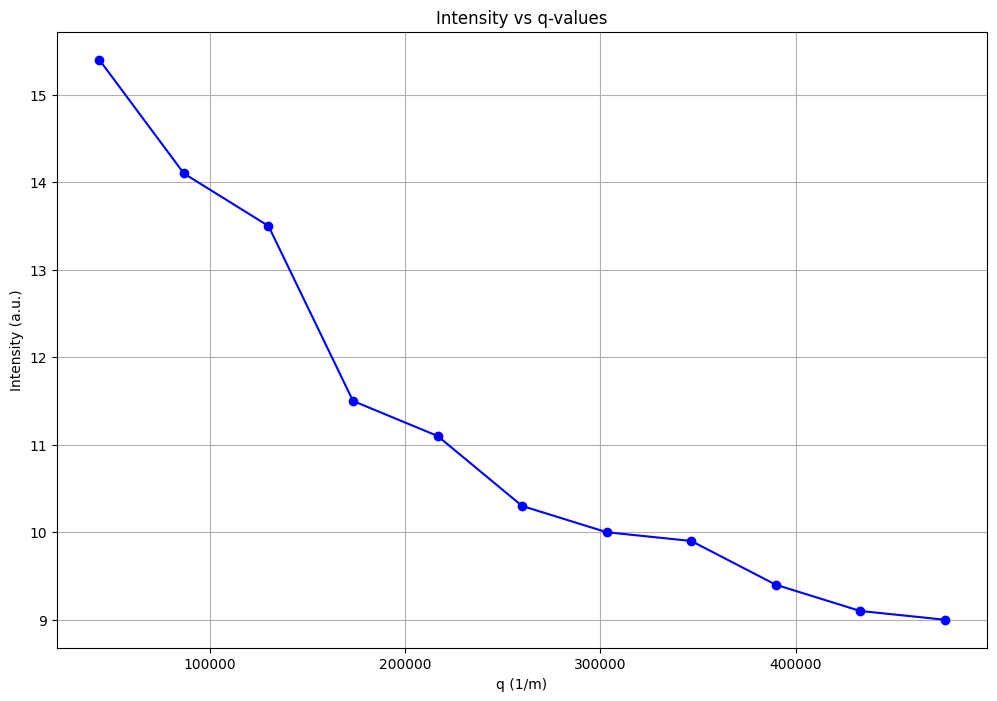

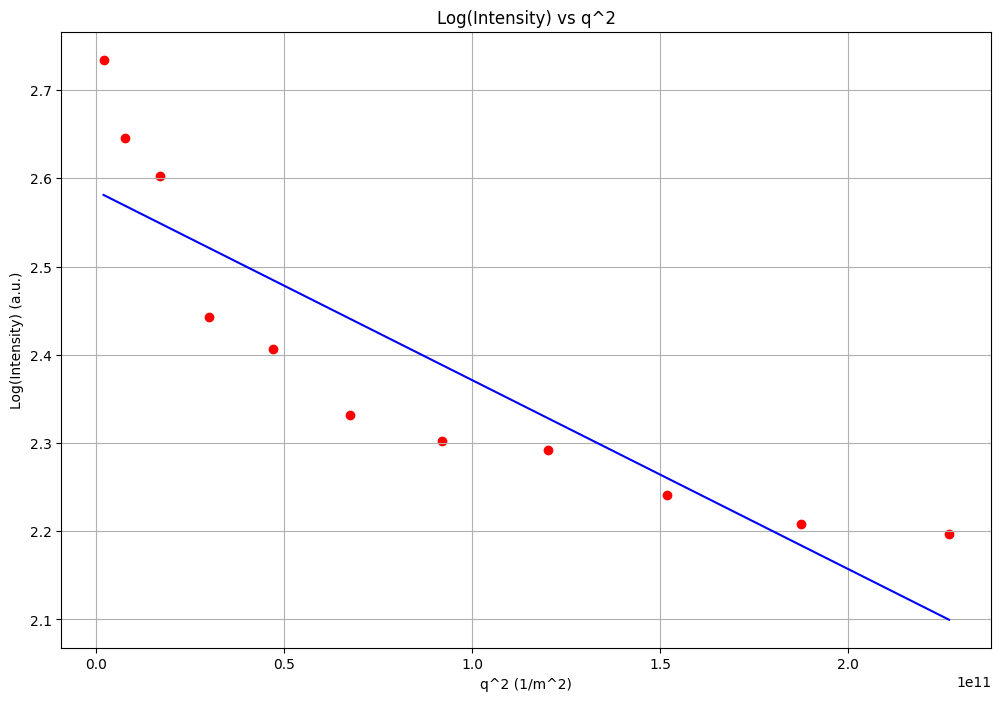

In [28]:
Wavelength = 632.8e-9

q_values = (2 * np.pi / Wavelength) * np.sin(np.deg2rad(Corrected_Angles/2))
q2_values = q_values**2
log_Intensities = np.log(Intensities)

plt.figure(figsize=(12,8))
plt.plot(q_values, Intensities, marker='o', linestyle='-', color='b')
plt.title('Intensity vs q-values')
plt.xlabel('q (1/m)')
plt.ylabel('Intensity (a.u.)')
plt.grid()
plt.show()

Best_fit = np.polyfit(q2_values, log_Intensities, 1)

plt.figure(figsize=(12,8))
plt.scatter(q2_values, log_Intensities, marker='o', linestyle='-', color='r')
plt.plot(q2_values, np.polyval(Best_fit, q2_values), color='b', label='Best Fit Line')
plt.title('Log(Intensity) vs q^2')
plt.xlabel('q^2 (1/m^2)')
plt.ylabel('Log(Intensity) (a.u.)')
plt.grid()
plt.show()